In [1]:
# Basic Imports
import numpy as np
import torch
torch.set_default_device("cuda")
torch.set_default_dtype(torch.float64)
from pydrake.geometry import Box as DrakeBox
from pydrake.geometry import Sphere as DrakeSphere
from dair_pll.geometry import (
    PydrakeToCollisionGeometryFactory,
    Polygon,
    Box,
    GeometryRepresentation,
    GeometryCollider,
)
from dair_pll.experiment_utils import chamfer_distance
from dair_pll.quaternion import quaternion_to_rotmat_vec

In [2]:
## Create Baseline Geometries
drake_sphere = DrakeSphere(0.0158)
drake_box = DrakeBox(0.04, 0.04, 0.04) # centered at model origin
dair_sphere = PydrakeToCollisionGeometryFactory.convert(drake_sphere, GeometryRepresentation.PRIMITIVE, learnable=False)
dair_box = PydrakeToCollisionGeometryFactory.convert(drake_box, GeometryRepresentation.PRIMITIVE, learnable=True)
dair_polygon = PydrakeToCollisionGeometryFactory.convert(drake_box, GeometryRepresentation.POLYGON, learnable=True)
# Box and polygon should have the same vertices
assert torch.all(torch.isclose(torch.sort(dair_box.get_vertices().detach(), dim=0)[0], torch.sort(dair_polygon.get_vertices().detach(), dim=0)[0]))

# And small Chamfer distance
sample_count = 10000
cdist = chamfer_distance(dair_box.sample_surface(sample_count), dair_polygon.sample_surface(sample_count))
print(f"Chamfer Dist: {cdist}")

Chamfer Dist: 0.0009681924423315636


In [3]:
# Pose Parameters
polygon_a = dair_polygon
sphere_b = dair_sphere
quat_AB = torch.nn.Parameter(torch.tensor([1., 0., 0., 0.]), requires_grad=True)
R_AB = quaternion_to_rotmat_vec(quat_AB).reshape((3, 3))
p_AoBo_A = torch.nn.Parameter(torch.tensor([-3.4748e-02, -1.1814e-06,  1.0297e-02]))
p_AoBo_B = p_AoBo_A @ R_AB

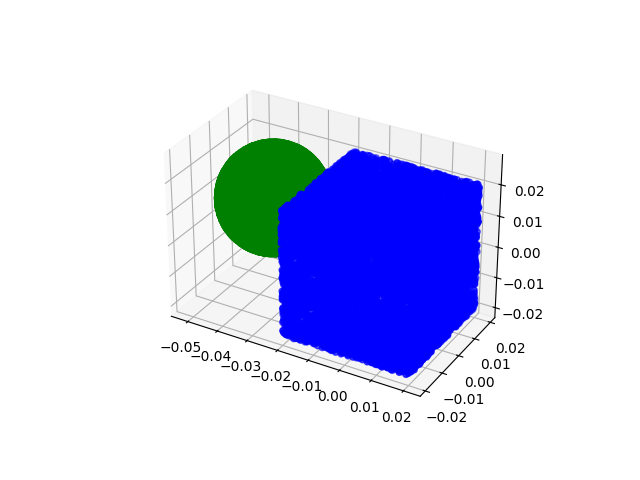

In [4]:
# Basic Plotting
%matplotlib widget
import matplotlib.pyplot as plt

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

# Make data
sphere_data = sphere_b.sample_surface(sample_count) + p_AoBo_B.detach().cpu().numpy()
polygon_data = polygon_a.sample_surface(sample_count)
# Plot the surfaces
ax.scatter(sphere_data[:, 0], sphere_data[:, 1], sphere_data[:, 2], color="green")
ax.scatter(polygon_data[:, 0], polygon_data[:, 1], polygon_data[:, 2], color="blue")

# Set an equal aspect ratio
ax.set_aspect('equal')

In [5]:
phi, R_AC, p_AoAc_A, p_BoBc_B = GeometryCollider.collide(dair_polygon, dair_sphere, R_AB.unsqueeze(0), p_AoBo_A.unsqueeze(0))

Using Jax


In [7]:
print(f"Contact Normal (polygon -> sphere in polygon frame): {R_AC[..., 2]}")
print(f"Contact Distance: {phi}")

Contact Normal (polygon -> sphere in polygon frame): tensor([[[-1.0000e+00, -2.5150e-07,  3.5122e-07]]], device='cuda:0',
       grad_fn=<SelectBackward0>)
Contact Distance: tensor([[-0.0011]], device='cuda:0', grad_fn=<SubBackward0>)


In [7]:
torch.autograd.grad(phi, list(dair_polygon.parameters()) + [p_AoBo_A, quat_AB], retain_graph=True, allow_unused=True)

(tensor([[ 1.6724e-07, -2.5000e-01,  2.2635e-07],
         [ 1.6724e-07, -2.5000e-01,  2.2635e-07],
         [ 2.0410e-14,  4.5139e-07, -9.0528e-14],
         [-4.0591e-13,  1.5630e-07, -4.3766e-13],
         [ 1.6724e-07, -2.5000e-01,  2.2635e-07],
         [ 1.6724e-07, -2.5000e-01,  2.2635e-07],
         [-3.5310e-13,  6.1844e-07, -5.0148e-13],
         [-1.4078e-13, -4.0663e-07, -6.6007e-14]]),
 tensor([-6.6897e-07,  1.0000e+00, -9.0539e-07]),
 tensor([0., 0., 0., 0.]))

In [8]:
phi

tensor([[0.3000]], grad_fn=<SubBackward0>)

In [25]:
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
import jax
import jax.numpy as jnp
from jaxopt import OSQP
from jax2torch import jax2torch

In [36]:
def closest_point_jax(osqp: OSQP, polygon_verts: jax.Array, point: jax.Array):
    assert polygon_verts.shape == (8, 3)
    assert point.shape == (3,)
    n_dims = 3
    n_verts = polygon_verts.shape[-2]
    Qj = polygon_verts @ polygon_verts.T
    qj = -point @ polygon_verts.T
    Gj = jnp.concatenate([-jnp.eye(n_verts), jnp.ones((1,n_verts))])
    hj = jnp.concatenate([jnp.zeros(n_verts), jnp.ones(1)])
    return osqp.run(params_obj=(Qj, qj), params_ineq=(Gj, hj)).params.primal @ polygon_verts

In [42]:
osqp = OSQP()
closest_point_to = jax2torch(jax.vmap(jax.jit(jax.tree_util.Partial(closest_point_jax, osqp)), in_axes=(None, 0)))

In [54]:
closest_point_to(dair_polygon.get_vertices(), p_AoBo_B.unsqueeze(0).expand(4, 3))

tensor([[-1.4843e-09,  5.0223e-01,  1.0914e-08],
        [-1.4843e-09,  5.0223e-01,  1.0914e-08],
        [-1.4843e-09,  5.0223e-01,  1.0914e-08],
        [-1.4843e-09,  5.0223e-01,  1.0914e-08]], grad_fn=<JaxFunBackward>)

In [23]:
cpt1 = dair_polygon.closest_point_to(p_AoBo_B.unsqueeze(0))

In [24]:
cpt2 = dair_polygon.closest_point_to_jax(dair_polygon.get_vertices(), p_AoBo_B.unsqueeze(0))

In [25]:
torch.dist(cpt1, cpt2)

tensor(0.0011, grad_fn=<DistBackward0>)

In [27]:
torch.autograd.grad(cpt2[0,0], list(dair_polygon.parameters()) + [p_AoBo_A, quat_AB], retain_graph=True, allow_unused=True)

(tensor([[ 1.0009e+00,  1.0119e-06, -2.3281e-08],
         [-9.2931e-06, -2.1067e-07, -7.5173e-08],
         [-2.9320e-06, -3.1383e-07, -1.1199e-07],
         [-1.5394e-04, -2.3752e-07, -8.4698e-08],
         [-9.5816e-06, -3.2976e-07, -1.1767e-07],
         [-1.4753e-04, -2.3909e-07, -8.5262e-08],
         [-1.5388e-04, -3.9227e-07, -1.3992e-07],
         [-3.0305e-04,  1.3770e-07,  4.9252e-08]]),
 tensor([3.9450e-07, 5.7769e-07, 5.9020e-07]),
 tensor([ 0.0000e+00, -1.0624e-06,  0.0000e+00,  7.1011e-07]))

In [14]:
cpt1.shape

torch.Size([1, 3])

In [12]:
dair_polygon.closest_point_to_jax(dair_polygon.get_vertices()/dair_polygon.bounding_radius(), p_AoBo_A.unsqueeze(0)/dair_polygon.bounding_radius()) * dair_polygon.bounding_radius()

tensor([[-2.0000e-02, -1.1703e-06,  1.0297e-02]], grad_fn=<MulBackward0>)

In [5]:
dair_polygon.closest_point_to(p_AoBo_A.unsqueeze(0))

tensor([[-2.0000e-02, -1.1811e-06,  1.0298e-02]], grad_fn=<MmBackward0>)

In [11]:
dair_polygon.bounding_radius()

tensor(0.0346)